# Insider Threat Detection — Model Building 


In [1]:
import os
import glob
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
    accuracy_score, confusion_matrix, classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Loading data

In [2]:
DATA_PATH = "/kaggle/input/datasets/tamannaranichoudhury/combined-df-labeled/combined_df_labeled.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)

(330452, 19)


## Data validation

In [3]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("Columns:", list(df.columns))
print("\nDtypes:")
print(df.dtypes)

Shape: 330,452 rows x 19 columns

Columns: ['user', 'day', 'logon_count', 'off_hours_logons', 'distinct_pcs', 'usb_connects', 'off_hours_usb', 'files_copied_to_usb', 'sensitive_files_to_usb', 'total_emails_sent', 'external_emails_sent', 'total_attachments', 'total_email_size', 'http_requests', 'cloud_job_visits', 'role_encoded', 'department_encoded', 'supervisor_encoded', 'is_insider']

Dtypes:
user                       object
day                        object
logon_count                 int64
off_hours_logons            int64
distinct_pcs                int64
usb_connects              float64
off_hours_usb             float64
files_copied_to_usb       float64
sensitive_files_to_usb    float64
total_emails_sent         float64
external_emails_sent      float64
total_attachments         float64
total_email_size          float64
http_requests             float64
cloud_job_visits          float64
role_encoded                int64
department_encoded          int64
supervisor_encoded      

In [4]:
df.head()

,user,day,logon_count,off_hours_logons,distinct_pcs,usb_connects,off_hours_usb,files_copied_to_usb,sensitive_files_to_usb,total_emails_sent,external_emails_sent,total_attachments,total_email_size,http_requests,cloud_job_visits,role_encoded,department_encoded,supervisor_encoded,is_insider
0,AAE0190,2010-01-04,1,1,1,0.0,0.0,0.0,0.0,14.0,1.0,4.0,441328.0,143.0,1.0,22,4,43,0
1,AAE0190,2010-01-05,1,1,1,0.0,0.0,0.0,0.0,13.0,5.0,2.0,355552.0,143.0,3.0,22,4,43,0
2,AAE0190,2010-01-06,1,1,1,0.0,0.0,0.0,0.0,14.0,6.0,12.0,532647.0,143.0,7.0,22,4,43,0
3,AAE0190,2010-01-07,1,1,1,0.0,0.0,0.0,0.0,14.0,5.0,9.0,474631.0,143.0,8.0,22,4,43,0
4,AAE0190,2010-01-08,1,1,1,0.0,0.0,0.0,0.0,13.0,2.0,10.0,400637.0,143.0,2.0,22,4,43,0


In [5]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
user                      0
day                       0
logon_count               0
off_hours_logons          0
distinct_pcs              0
usb_connects              0
off_hours_usb             0
files_copied_to_usb       0
sensitive_files_to_usb    0
total_emails_sent         0
external_emails_sent      0
total_attachments         0
total_email_size          0
http_requests             0
cloud_job_visits          0
role_encoded              0
department_encoded        0
supervisor_encoded        0
is_insider                0
dtype: int64

Duplicate rows: 0


In [6]:
print("Target distribution (is_insider):")
print(df["is_insider"].value_counts())
print(df["is_insider"].value_counts(normalize=True) * 100)

pos_rate = df["is_insider"].mean()
print(f"\nPositive class rate: {pos_rate*100:.3f}%")

Target distribution (is_insider):
is_insider
0    329466
1       986
Name: count, dtype: int64
is_insider
0    99.701621
1     0.298379
Name: proportion, dtype: float64

Positive class rate: 0.298%


## Feature / target separation

- Target: `is_insider`
- Excluded from predictors: `user`, `day` 
- Everything else (logon/device/file/email/http counts + the LDAP-derived `role_encoded`, `department_encoded`, `supervisor_encoded`) is kept as a predictor

In [7]:
ID_COLS = ["user", "day"]
TARGET_COL = "is_insider"

feature_cols = [c for c in df.columns if c not in ID_COLS + [TARGET_COL]]
print(f"Using {len(feature_cols)} predictor columns:")
print(feature_cols)

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

Using 16 predictor columns:
['logon_count', 'off_hours_logons', 'distinct_pcs', 'usb_connects', 'off_hours_usb', 'files_copied_to_usb', 'sensitive_files_to_usb', 'total_emails_sent', 'external_emails_sent', 'total_attachments', 'total_email_size', 'http_requests', 'cloud_job_visits', 'role_encoded', 'department_encoded', 'supervisor_encoded']


## Train / test split (before SMOTE)



In [8]:
id_df = df[ID_COLS].copy()

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, id_df,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, positives: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Test:  {X_test.shape}, positives: {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Train: (264361, 16), positives: 789 (0.298%)
Test:  (66091, 16), positives: 197 (0.298%)


## Class imbalance / SMOTE

Class distribution before SMOTE (train only), and after SMOTE is applied to the training data as a sanity check. In cross-validation and the final tuned pipeline, SMOTE lives inside an `imblearn` Pipeline so it only ever touches the training fold — validation folds and the held-out test set stay in their real, imbalanced form.

In [9]:
print("Before SMOTE (train):")
print(y_train.value_counts())

smote_check = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = smote_check.fit_resample(X_train, y_train)

print("\nAfter SMOTE (train, illustrative only - not used directly for CV):")
print(pd.Series(y_res).value_counts())

del X_res, y_res, smote_check

Before SMOTE (train):
is_insider
0    263572
1       789
Name: count, dtype: int64

After SMOTE (train, illustrative only - not used directly for CV):
is_insider
0    263572
1    263572
Name: count, dtype: int64


## Cross-validated model comparison: Random Forest vs XGBoost

`StratifiedKFold(3)` on `X_train`/`y_train`. Each model is wrapped as `SMOTE -> classifier` inside an `imblearn` Pipeline so oversampling happens fresh on each training fold only. F1 is the primary selection metric given the severe imbalance; Precision/Recall/ROC-AUC/PR-AUC are tracked alongside it.

In [10]:
def cv_evaluate(pipeline, X, y, cv):
    metrics = {"precision": [], "recall": [], "f1": [], "roc_auc": [], "pr_auc": []}
    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        preds = pipeline.predict(X_val)
        proba = pipeline.predict_proba(X_val)[:, 1]

        metrics["precision"].append(precision_score(y_val, preds, zero_division=0))
        metrics["recall"].append(recall_score(y_val, preds, zero_division=0))
        metrics["f1"].append(f1_score(y_val, preds, zero_division=0))
        metrics["roc_auc"].append(roc_auc_score(y_val, proba))
        metrics["pr_auc"].append(average_precision_score(y_val, proba))

    return {k: float(np.mean(v)) for k, v in metrics.items()}


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])

xgb_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
    ))
])

rf_cv_results = cv_evaluate(rf_pipeline, X_train, y_train, cv)
xgb_cv_results = cv_evaluate(xgb_pipeline, X_train, y_train, cv)

print("Random Forest CV:", rf_cv_results)
print("XGBoost CV:", xgb_cv_results)

Random Forest CV: {'precision': 0.9224029147658516, 'recall': 0.49809885931558934, 'f1': 0.6467570009033424, 'roc_auc': 0.986782779337943, 'pr_auc': 0.7981540908109631}
XGBoost CV: {'precision': 0.8649013081935283, 'recall': 0.779467680608365, 'f1': 0.8196415121592389, 'roc_auc': 0.9901306742804098, 'pr_auc': 0.8598967285592926}


## Isolation Forest (separate, unsupervised)

In [11]:
iso_contamination = float(np.clip(y_train.mean(), 0.005, 0.05))
print(f"Isolation Forest contamination set to: {iso_contamination:.4f}")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=iso_contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_forest.fit(X_train)

# Higher = more anomalous (flip sign of score_samples)
train_anomaly_raw = -iso_forest.score_samples(X_train)
print("Isolation Forest fit. Raw anomaly score range (train):",
      train_anomaly_raw.min(), "to", train_anomaly_raw.max())

Isolation Forest contamination set to: 0.0050
Isolation Forest fit. Raw anomaly score range (train): 0.3576538762964896 to 0.7808641803818256


## Model comparison table 

In [12]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Precision": [rf_cv_results["precision"], xgb_cv_results["precision"]],
    "Recall": [rf_cv_results["recall"], xgb_cv_results["recall"]],
    "F1": [rf_cv_results["f1"], xgb_cv_results["f1"]],
    "ROC-AUC": [rf_cv_results["roc_auc"], xgb_cv_results["roc_auc"]],
    "PR-AUC": [rf_cv_results["pr_auc"], xgb_cv_results["pr_auc"]],
})
comparison_df = comparison_df.set_index("Model")
print(comparison_df.round(4))

winner = comparison_df["F1"].idxmax()
print(f"\nSelected model (highest mean CV F1): {winner}")

               Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                    
Random Forest     0.9224  0.4981  0.6468   0.9868  0.7982
XGBoost           0.8649  0.7795  0.8196   0.9901  0.8599

Selected model (highest mean CV F1): XGBoost


## Hyperparameter tuning 



In [13]:
if winner == "Random Forest":
    base_pipeline = rf_pipeline
    param_distributions = {
        "clf__n_estimators": [100, 200, 300, 400],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_features": ["sqrt", "log2"],
    }
else:
    base_pipeline = xgb_pipeline
    param_distributions = {
        "clf__n_estimators": [100, 200, 300, 400],
        "clf__max_depth": [3, 5, 7, 9],
        "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "clf__subsample": [0.7, 0.8, 0.9, 1.0],
        "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    }

search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print(f"Best CV F1: {search.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'clf__subsample': 0.9, 'clf__n_estimators': 400, 'clf__max_depth': 5, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 0.9}
Best CV F1: 0.8650


## Final model refit


In [14]:
final_pipeline = search.best_estimator_
final_pipeline

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.9, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.2,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## Final evaluation on the untouched test set

In [15]:
test_preds = final_pipeline.predict(X_test)
test_proba = final_pipeline.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, test_preds)
test_precision = precision_score(y_test, test_preds, zero_division=0)
test_recall = recall_score(y_test, test_preds, zero_division=0)
test_f1 = f1_score(y_test, test_preds, zero_division=0)
test_roc_auc = roc_auc_score(y_test, test_proba)
test_pr_auc = average_precision_score(y_test, test_proba)
test_cm = confusion_matrix(y_test, test_preds)

print(f"Model: {winner} (tuned)\n")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1:        {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print(f"PR-AUC:    {test_pr_auc:.4f}")
print("\nConfusion matrix:")
print(test_cm)
print("\nClassification report:")
print(classification_report(y_test, test_preds, target_names=["Normal", "Insider"], zero_division=0))

print("\n--- CV (model selection) vs Test (final) ---")
print(f"CV F1 (from tuning):  {search.best_score_:.4f}")
print(f"Test F1 (held-out):   {test_f1:.4f}")

Model: XGBoost (tuned)

Accuracy:  0.9994
Precision: 0.9588
Recall:    0.8274
F1:        0.8883
ROC-AUC:   0.9887
PR-AUC:    0.9350

Confusion matrix:
[[65887     7]
 [   34   163]]

Classification report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     65894
     Insider       0.96      0.83      0.89       197

    accuracy                           1.00     66091
   macro avg       0.98      0.91      0.94     66091
weighted avg       1.00      1.00      1.00     66091


--- CV (model selection) vs Test (final) ---
CV F1 (from tuning):  0.8650
Test F1 (held-out):   0.8883


## Feature importance

usb_connects              0.466941
off_hours_usb             0.122227
logon_count               0.111969
files_copied_to_usb       0.096486
cloud_job_visits          0.059431
http_requests             0.030167
sensitive_files_to_usb    0.029782
total_emails_sent         0.016514
role_encoded              0.016023
department_encoded        0.015616
total_attachments         0.009134
off_hours_logons          0.009131
external_emails_sent      0.007136
supervisor_encoded        0.004802
distinct_pcs              0.002435
total_email_size          0.002205
dtype: float32


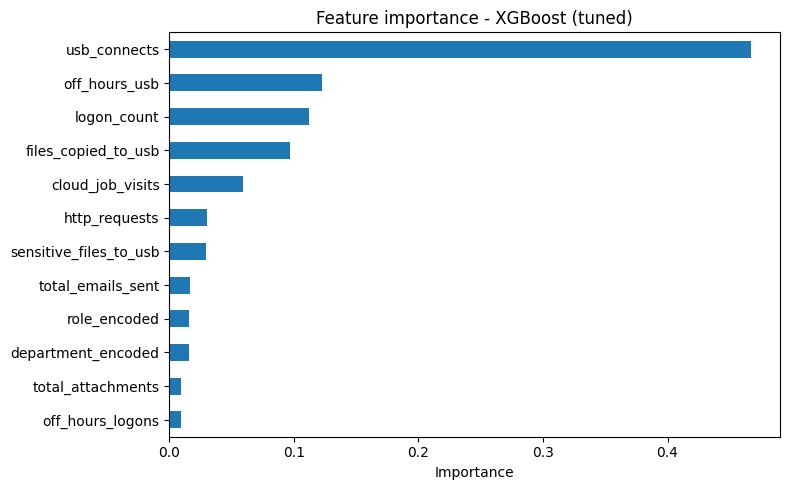

In [16]:
clf_step = final_pipeline.named_steps["clf"]
importances = pd.Series(clf_step.feature_importances_, index=feature_cols).sort_values(ascending=False)

print(importances)

plt.figure(figsize=(8, 5))
importances.head(12).sort_values().plot(kind="barh")
plt.title(f"Feature importance - {winner} (tuned)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()

## Behavioural risk signals

Each component below is built only from columns that actually exist in `combined_df_labeled.csv`. Where the project's risk category has no directly-observed feature (Historical Security Events), a clearly-labelled proxy is used instead.

| Component | Weight | Features used | Basis |
|---|---|---|---|
| Behavioral Anomalies | 35% | `off_hours_logons`, `off_hours_usb` | Directly observed off-hours activity |
| Privilege Misuse Indicators | 25% | `usb_connects`, `files_copied_to_usb`, `sensitive_files_to_usb` | Directly observed removable-media / file-copy activity |
| Data Access Violations | 20% | `sensitive_files_to_usb`, `external_emails_sent`, `total_attachments`, `total_email_size` | Directly observed sensitive-file and outbound-email activity (possible exfiltration) |
| Access Pattern Deviations | 10% | `distinct_pcs`, `http_requests`, `cloud_job_visits` | Directly observed multi-machine logins and cloud/job-site browsing |
| Historical Security Events | 10% | **Proxy**: per-user cumulative count of the above flagged events on *prior* days | No incident/alert log exists in this dataset — proxy stands in for "history of flagged behaviour" for that user, computed only from strictly earlier days (no leakage from the current or future rows) |

Each raw component is min-max normalised to 0-1 (clipped at the 99th percentile, fit on the training set only) before weighting.

In [17]:
BEHAVIORAL_ANOMALY_COLS = ["off_hours_logons", "off_hours_usb"]
PRIVILEGE_MISUSE_COLS = ["usb_connects", "files_copied_to_usb", "sensitive_files_to_usb"]
DATA_ACCESS_COLS = ["sensitive_files_to_usb", "external_emails_sent", "total_attachments", "total_email_size"]
ACCESS_PATTERN_COLS = ["distinct_pcs", "http_requests", "cloud_job_visits"]
HISTORICAL_PROXY_SOURCE_COLS = ["off_hours_logons", "off_hours_usb", "sensitive_files_to_usb", "external_emails_sent"]

RISK_WEIGHTS = {
    "behavioral_anomalies": 0.35,
    "privilege_misuse": 0.25,
    "data_access_violations": 0.20,
    "access_pattern_deviations": 0.10,
    "historical_security_events": 0.10,
}
assert abs(sum(RISK_WEIGHTS.values()) - 1.0) < 1e-9
print(RISK_WEIGHTS)

{'behavioral_anomalies': 0.35, 'privilege_misuse': 0.25, 'data_access_violations': 0.2, 'access_pattern_deviations': 0.1, 'historical_security_events': 0.1}


In [18]:
def build_historical_proxy(full_df):
    """Per-user cumulative count of prior flagged behavioural events (shifted so
    the current day's own values are never included -> no leakage)."""
    tmp = full_df[["user", "day"] + HISTORICAL_PROXY_SOURCE_COLS].copy()
    tmp["day"] = pd.to_datetime(tmp["day"])
    tmp = tmp.sort_values(["user", "day"])
    tmp["daily_flag_count"] = tmp[HISTORICAL_PROXY_SOURCE_COLS].sum(axis=1)
    tmp["historical_events_proxy"] = (
        tmp.groupby("user")["daily_flag_count"].cumsum() - tmp["daily_flag_count"]
    )
    return tmp.set_index(tmp.index)["historical_events_proxy"]


df["historical_events_proxy"] = build_historical_proxy(df)

In [19]:
def raw_components(frame, hist_series):
    return pd.DataFrame({
        "behavioral_anomalies_raw": frame[BEHAVIORAL_ANOMALY_COLS].sum(axis=1),
        "privilege_misuse_raw": frame[PRIVILEGE_MISUSE_COLS].sum(axis=1),
        "data_access_violations_raw": frame[DATA_ACCESS_COLS].sum(axis=1),
        "access_pattern_deviations_raw": frame[ACCESS_PATTERN_COLS].sum(axis=1),
        "historical_security_events_raw": hist_series.loc[frame.index],
    }, index=frame.index)


train_components = raw_components(df.loc[X_train.index], df["historical_events_proxy"])
test_components = raw_components(df.loc[X_test.index], df["historical_events_proxy"])

# Fit normalisation caps on TRAIN only, apply to both
norm_config = {}
train_components_norm = pd.DataFrame(index=train_components.index)
test_components_norm = pd.DataFrame(index=test_components.index)

for col in train_components.columns:
    cap = float(np.percentile(train_components[col], 99)) or 1.0
    norm_config[col] = {"min": 0.0, "cap_p99": cap}
    train_components_norm[col] = (train_components[col].clip(0, cap) / cap)
    test_components_norm[col] = (test_components[col].clip(0, cap) / cap)

print(pd.DataFrame(norm_config).T)

                                min   cap_p99
behavioral_anomalies_raw        0.0       7.0
privilege_misuse_raw            0.0      56.0
data_access_violations_raw      0.0  590190.2
access_pattern_deviations_raw   0.0     199.0
historical_security_events_raw  0.0    6090.4


In [20]:
component_to_weight = {
    "behavioral_anomalies_raw": RISK_WEIGHTS["behavioral_anomalies"],
    "privilege_misuse_raw": RISK_WEIGHTS["privilege_misuse"],
    "data_access_violations_raw": RISK_WEIGHTS["data_access_violations"],
    "access_pattern_deviations_raw": RISK_WEIGHTS["access_pattern_deviations"],
    "historical_security_events_raw": RISK_WEIGHTS["historical_security_events"],
}

def weighted_behavioral_score(components_norm):
    score = sum(components_norm[c] * w for c, w in component_to_weight.items())
    return (score * 100).clip(0, 100)

test_behavioral_risk = weighted_behavioral_score(test_components_norm)
print(test_behavioral_risk.describe())

count    66091.000000
mean        18.266962
std         11.891996
min          0.145483
25%          9.715715
50%         17.461053
75%         24.054387
max         89.791447
dtype: float64


## Combine ML + behavioural risk into an overall score


In [21]:
ml_score_component = test_proba * 100
overall_risk_score = 0.5 * ml_score_component + 0.5 * test_behavioral_risk.values
overall_risk_score = pd.Series(overall_risk_score, index=X_test.index).clip(0, 100)

test_iso_anomaly_raw = -iso_forest.score_samples(X_test)
iso_cap = float(np.percentile(-iso_forest.score_samples(X_train), 99)) or 1.0
test_iso_anomaly_norm = pd.Series(
    np.clip(test_iso_anomaly_raw, 0, iso_cap) / iso_cap, index=X_test.index
)

overall_risk_score.describe()

count    66091.000000
mean         9.270365
std          6.456945
min          0.098606
25%          4.869885
50%          8.756802
75%         12.059029
max         88.397845
dtype: float64

## Severity categories

| Score range | Severity |
|---|---|
| 0-25 | Low |
| 25-50 | Medium |
| 50-75 | High |
| 75-100 | Critical |

Fixed quartile thresholds, set before looking at the resulting distribution.

In [22]:
SEVERITY_THRESHOLDS = [(0, 25, "Low"), (25, 50, "Medium"), (50, 75, "High"), (75, 100.0001, "Critical")]

def score_to_severity(score):
    for low, high, label in SEVERITY_THRESHOLDS:
        if low <= score < high:
            return label
    return "Critical"

severity = overall_risk_score.apply(score_to_severity)
print(severity.value_counts())

Low         64038
Medium       1899
High          151
Critical        3
Name: count, dtype: int64


## Final user-day risk table

In [23]:
risk_table = pd.DataFrame({
    "user": id_test.loc[X_test.index, "user"].values,
    "day": id_test.loc[X_test.index, "day"].values,
    "actual_is_insider": y_test.values,
    "predicted_insider": test_preds,
    "insider_probability": test_proba,
    "isolation_forest_anomaly": test_iso_anomaly_norm.values,
    "behavioral_risk_score": test_behavioral_risk.values,
    "overall_risk_score": overall_risk_score.values,
    "severity": severity.values,
}, index=X_test.index)

risk_table = risk_table.sort_values("overall_risk_score", ascending=False)

print(f"Total test user-days: {len(risk_table):,}")
print(f"Predicted insider user-days: {risk_table['predicted_insider'].sum():,}")
print(f"High/Critical severity user-days: {(risk_table['severity'].isin(['High','Critical'])).sum():,}")

risk_table.head(20)

Total test user-days: 66,091
Predicted insider user-days: 170
High/Critical severity user-days: 154


,user,day,actual_is_insider,predicted_insider,insider_probability,isolation_forest_anomaly,behavioral_risk_score,overall_risk_score,severity
222696,MOS0047,2010-07-20,1,1,0.955716,1.000000,81.224127,88.397845,Critical
44264,BSS0369,2010-09-30,1,1,0.792007,1.000000,81.400968,80.300826,Critical
167584,JLM0364,2011-04-28,1,1,0.991013,1.000000,55.078790,77.090028,Critical
203457,LQC0479,2010-09-15,1,1,0.999858,0.787200,40.642421,70.314092,High
196221,LCC0819,2010-08-10,1,1,0.998231,0.848021,39.601884,69.712487,High
168067,JMB0308,2010-07-15,1,1,0.999509,0.749031,38.553908,69.252395,High
203461,LQC0479,2010-09-21,1,1,0.999775,0.750946,37.591614,68.784538,High
222704,MOS0047,2010-07-30,1,1,0.677722,1.000000,65.445612,66.608918,High
189906,KRL0501,2010-12-15,1,1,0.998425,0.773643,33.263575,66.553048,High
15079,AKR0057,2010-11-15,1,1,0.999687,0.789481,31.847093,65.907906,High


In [24]:
os.makedirs("/kaggle/working", exist_ok=True)

with open("/kaggle/working/final_model.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)

with open("/kaggle/working/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

risk_scoring_config = {
    "component_weights": RISK_WEIGHTS,
    "component_features": {
        "behavioral_anomalies": BEHAVIORAL_ANOMALY_COLS,
        "privilege_misuse": PRIVILEGE_MISUSE_COLS,
        "data_access_violations": DATA_ACCESS_COLS,
        "access_pattern_deviations": ACCESS_PATTERN_COLS,
        "historical_security_events_proxy_source": HISTORICAL_PROXY_SOURCE_COLS,
    },
    "normalization": norm_config,
    "ml_vs_behavioral_blend": {"ml_probability_weight": 0.5, "behavioral_score_weight": 0.5},
    "severity_thresholds": [{"min": lo, "max": hi, "label": lbl} for lo, hi, lbl in SEVERITY_THRESHOLDS],
    "isolation_forest_contamination": iso_contamination,
    "selected_model": winner,
}
with open("/kaggle/working/risk_scoring_config.json", "wb") as f:
    f.write(json.dumps(risk_scoring_config, indent=2).encode("utf-8"))

with open("/kaggle/working/isolation_forest.pkl", "wb") as f:
    pickle.dump(iso_forest, f)

print("Saved: final_model.pkl, feature_columns.pkl, risk_scoring_config.json, isolation_forest.pkl")
print(os.listdir("/kaggle/working"))

Saved: final_model.pkl, feature_columns.pkl, risk_scoring_config.json, isolation_forest.pkl
['__notebook__.ipynb', 'feature_importance.png', 'risk_scoring_config.json', 'isolation_forest.pkl', 'final_model.pkl', 'feature_columns.pkl']


## Reload verification

In [25]:
with open("/kaggle/working/final_model.pkl", "rb") as f:
    reloaded_model = pickle.load(f)

with open("/kaggle/working/feature_columns.pkl", "rb") as f:
    reloaded_features = pickle.load(f)

with open("/kaggle/working/risk_scoring_config.json", "rb") as f:
    reloaded_config = json.loads(f.read().decode("utf-8"))

with open("/kaggle/working/isolation_forest.pkl", "rb") as f:
    reloaded_iso = pickle.load(f)

sample = X_test[reloaded_features].head(5)
reloaded_preds = reloaded_model.predict(sample)
reloaded_proba = reloaded_model.predict_proba(sample)[:, 1]

print("Reloaded feature columns match:", reloaded_features == feature_cols)
print("Reloaded predictions:", reloaded_preds)
print("Reloaded probabilities:", np.round(reloaded_proba, 4))
print("Matches original predictions on same sample:",
      np.array_equal(reloaded_preds, final_pipeline.predict(sample)))
print("Reloaded risk config keys:", list(reloaded_config.keys()))
print("Isolation Forest reload OK:", hasattr(reloaded_iso, "score_samples"))

Reloaded feature columns match: True
Reloaded predictions: [0 0 0 0 0]
Reloaded probabilities: [0.0001 0.     0.0031 0.     0.0008]
Matches original predictions on same sample: True
Reloaded risk config keys: ['component_weights', 'component_features', 'normalization', 'ml_vs_behavioral_blend', 'severity_thresholds', 'isolation_forest_contamination', 'selected_model']
Isolation Forest reload OK: True


## Final results summary

In [26]:
summary = {
    "selected_model": winner,
    "cv_f1": round(search.best_score_, 4),
    "test_precision": round(test_precision, 4),
    "test_recall": round(test_recall, 4),
    "test_f1": round(test_f1, 4),
    "test_roc_auc": round(test_roc_auc, 4),
    "test_pr_auc": round(test_pr_auc, 4),
    "confusion_matrix": test_cm.tolist(),
    "insider_cases_in_test": int(y_test.sum()),
    "insider_cases_correctly_detected": int(((test_preds == 1) & (y_test == 1)).sum()),
    "risk_score_distribution": overall_risk_score.describe().round(2).to_dict(),
    "severity_distribution": severity.value_counts().to_dict(),
}

for k, v in summary.items():
    print(f"{k}: {v}")

selected_model: XGBoost
cv_f1: 0.865
test_precision: 0.9588
test_recall: 0.8274
test_f1: 0.8883
test_roc_auc: 0.9887
test_pr_auc: 0.935
confusion_matrix: [[65887, 7], [34, 163]]
insider_cases_in_test: 197
insider_cases_correctly_detected: 163
risk_score_distribution: {'count': 66091.0, 'mean': 9.27, 'std': 6.46, 'min': 0.1, '25%': 4.87, '50%': 8.76, '75%': 12.06, 'max': 88.4}
severity_distribution: {'Low': 64038, 'Medium': 1899, 'High': 151, 'Critical': 3}
